# A velocity-compensated gradient echo

A gradient echo puts `k = 0` at the echo by cancelling the readout gradient's area with a
prephaser. That makes the **zeroth** moment zero there — so a stationary spin arrives with no
phase from the readout axis. It says nothing about the **first** moment, which is not zero, and a
spin moving along the readout direction does arrive with a phase:

$$\phi \;=\; 2\pi \int G(t)\,x(t)\,\mathrm{d}t \;=\; 2\pi\,(m_0 x_0 + m_1 v)$$

Flowing blood, CSF and a moving vessel wall all carry that term, and it varies from shot to shot
with the flow, which is why motion along a gradient axis shows up in an image.

**Flow compensation** — gradient moment nulling — removes it by reshaping the waveform so that
$m_1 = 0$ at the echo as well as $m_0$. On a Cartesian readout the canonical construction uses
three lobes before the echo instead of two:

```text
ordinary        [ winder ] [ readout ->  echo ...        m0 = 0, m1 != 0
compensated  [ w1 ][ w2 ] [ readout ->  echo ...         m0 = 0, m1 = 0
```

In SeqCraft that is not a separate block you insert: it is the readout's own prephaser, reshaped
by `CartesianLine(null_moment_order=1)`.

| | |
|---|---|
| **1** | the moments of an ordinary readout |
| **2** | nulling the first moment |
| **3** | the moments of the emitted waveform |
| **4** | what it costs |
| **5** | a complete acquisition |
| **6** | the files |

**Output:** two `.seq` files, an ordinary gradient echo and a velocity-compensated one.
**Needs nothing but `seqcraft`.**

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pypulseq as pp

import seqcraft as sc

opts = pp.Opts(
    max_grad=40, grad_unit='mT/m',
    max_slew=150, slew_unit='T/m/s',
    B0=3.0,
    rf_dead_time=100e-6,
    rf_ringdown_time=30e-6,
    adc_dead_time=10e-6,
)

FOV_MM, MATRIX, THICKNESS_MM = 220.0, 64, 5.0
BANDWIDTH_HZ_PX = 500.0
SEQ_DIR = Path('seq')
SEQ_DIR.mkdir(exist_ok=True)
raster = sc.Raster(opts.grad_raster_time)

/opt/homebrew/Caskroom/miniforge/base/envs/seqcraft-dev/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## 1. The moments of an ordinary readout

A moment needs three things named before it is a number: the **axis**, the **order**, and the
**instant** it is taken about. Here they are the readout axis, orders 0 and 1, and the echo — the
sample where `k = 0`, which `time_to_echo()` gives.

The measurement below integrates every gradient event on the axis from its own piecewise-linear
knots, truncates at the echo, and sums. Summing matters: the winder and the readout lobe are
separate events, and it is only together that their moments mean anything.

In [2]:
def moment_at_echo(module, order, echo_index=0):
    """The order-th moment of every gradient on the module's axis, at one echo, about it."""
    echo = module.te_s[echo_index]
    total = 0.0
    for start, event, _ in sc.flatten(module()):
        if getattr(event, 'type', None) not in ('trap', 'grad'):
            continue
        if getattr(event, 'channel', None) != module.axis:
            continue
        times, amps = sc.events.knots_of(event, start)
        if times.size < 2 or echo <= times[0]:
            continue
        if echo < times[-1]:                      # the readout lobe straddles the echo
            cut = int(np.searchsorted(times, echo))
            edge = float(np.interp(echo, times, amps))
            times, amps = np.append(times[:cut], echo), np.append(amps[:cut], edge)
        total += sc.events.pwl_moment(times - echo, amps, order)
    return float(total)


plain = sc.modules.CartesianLine(opts=opts, fov_mm=FOV_MM, matrix=MATRIX,
                                 bandwidth_hz_px=BANDWIDTH_HZ_PX)

print(f'an ordinary readout, echo at {plain.time_to_echo() * 1e3:.3f} ms\n')
print(f'   m0 at the echo   {moment_at_echo(plain, 0):+12.3e}  1/m')
print(f'   m1 at the echo   {moment_at_echo(plain, 1):+12.3e}  s/m')
print(f'\na spin moving at 0.5 m/s along {plain.axis} therefore arrives with '
      f'{2 * np.pi * moment_at_echo(plain, 1) * 0.5 / np.pi:+.2f} pi of phase')

an ordinary readout, echo at 1.364 ms

   m0 at the echo     +5.684e-14  1/m
   m1 at the echo     +1.034e-01  s/m

a spin moving at 0.5 m/s along x therefore arrives with +0.10 pi of phase


`m0` is zero — that is what the prephaser is for, and it is why a stationary spin is unaffected.
`m1` is not, and at a metre per second it is worth a substantial fraction of a cycle. That phase
is what flow compensation removes.

---
## 2. Nulling the first moment

`null_moment_order=1` reshapes the prephaser into **two** lobes of opposite sign. Their areas are
solved so that, together with the readout's own contribution up to the echo, both conditions hold
at once:

```text
A1 + A2 + (readout area to the echo)              = 0
A1 t1 + A2 t2 + (readout first moment to the echo) = 0
```

Both are linear in the two areas, so the solve is closed form rather than a search. The readout
lobe is untouched — only the winder changes.

In [3]:
compensated = sc.modules.CartesianLine(opts=opts, fov_mm=FOV_MM, matrix=MATRIX,
                                       bandwidth_hz_px=BANDWIDTH_HZ_PX, null_moment_order=1)

print(f'{"":>14}{"lobes":>7}{"areas / (1/m)":>28}{"total":>12}{"-area_to_echo":>16}')
for name, module in (('ordinary', plain), ('compensated', compensated)):
    areas = [float(lobe.area) for lobe in module.prephaser_lobes]
    written = '  '.join(f'{a:+9.2f}' for a in areas)
    print(f'{name:>14}{len(areas):7d}{written:>28}{sum(areas):+12.2f}'
          f'{-module.area_to_echo_per_m:+16.2f}')

                lobes               areas / (1/m)       total   -area_to_echo
      ordinary      1                     -149.91     -149.91         -149.91
   compensated      2          +233.70    -383.62     -149.91         -149.91


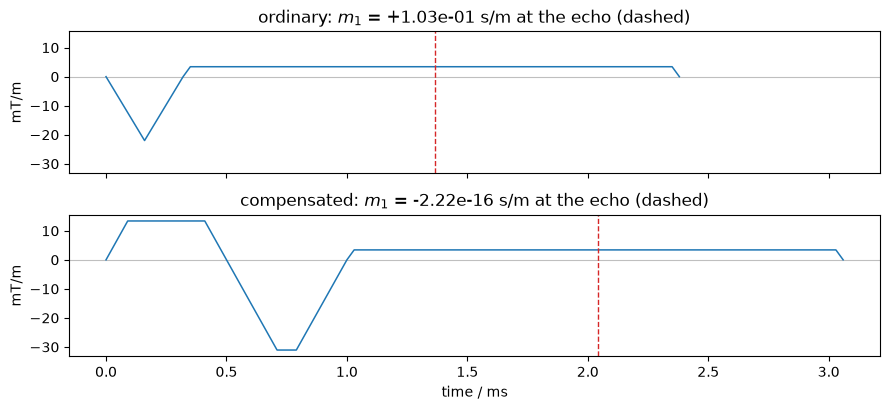

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(9.0, 4.2), sharex=True, sharey=True)
for ax, (name, module) in zip(axes, (('ordinary', plain), ('compensated', compensated))):
    grid, grads, _ = sc.sample(module(), opts)
    ax.plot(grid * 1e3, grads[module.axis] / 42.576e6 * 1e3, lw=1.1)
    ax.axvline(module.time_to_echo() * 1e3, color='C3', ls='--', lw=1.0)
    ax.axhline(0.0, color='0.75', lw=0.8, zorder=0)
    ax.set(ylabel='mT/m', title=f'{name}: $m_1$ = {moment_at_echo(module, 1):+.2e} s/m '
                                f'at the echo (dashed)')
axes[-1].set(xlabel='time / ms')
fig.tight_layout()

The compensated winder is two lobes rather than one, and the readout lobe after them is
identical. The dashed line is the echo, which is where both moments are taken.

---
## 3. The moments of the emitted waveform

The same measurement as section 1, now for both, and across three protocols — because the solve
reads the readout lobe's *measured* shape, so a different matrix or bandwidth is a different
problem to solve rather than the same answer scaled.

In [5]:
print(f'{"protocol":>18}{"order":>18}{"ordinary":>14}{"compensated":>14}')
for matrix, bandwidth in ((64, 500.0), (128, 250.0), (32, 1000.0)):
    pair = [sc.modules.CartesianLine(opts=opts, fov_mm=FOV_MM, matrix=matrix,
                                     bandwidth_hz_px=bandwidth, null_moment_order=order)
            for order in (0, 1)]
    label = f'{matrix} px, {bandwidth:.0f} Hz/px'
    for order, unit in ((0, '1/m'), (1, 's/m')):
        values = ''.join(f'{moment_at_echo(module, order):14.2e}' for module in pair)
        print(f'{label if order == 0 else "":>18}{f"m{order} / ({unit})":>18}{values}')

          protocol             order      ordinary   compensated
  64 px, 500 Hz/px        m0 / (1/m)      5.68e-14      1.42e-13
                          m1 / (s/m)      1.03e-01     -2.22e-16
 128 px, 250 Hz/px        m0 / (1/m)      1.14e-13      1.71e-13
                          m1 / (s/m)      3.69e-01     -3.89e-16
 32 px, 1000 Hz/px        m0 / (1/m)     -1.42e-14     -2.84e-14
                          m1 / (s/m)      3.01e-02      2.43e-17


`m0` stays at the arithmetic floor in both columns — the echo condition is not traded away — and
`m1` falls from something physical to the floor as well.

The gradient waveform has to remain playable, so it is worth checking that the compensation was
not bought by exceeding the amplifier:

In [6]:
print(f'{"lobe":>6}{"area / (1/m)":>15}{"amplitude / %max":>18}{"slew / %max":>14}')
for index, lobe in enumerate(compensated.prephaser_lobes):
    amplitude = abs(float(lobe.amplitude))
    print(f'{index:6d}{float(lobe.area):+15.2f}{amplitude / opts.max_grad * 100:18.1f}'
          f'{amplitude / float(lobe.rise_time) / opts.max_slew * 100:14.1f}')

  lobe   area / (1/m)  amplitude / %max   slew / %max
     0        +233.70              33.5          99.2
     1        -383.62              77.7          98.6


---
## 4. What it costs

Three lobes before the echo instead of two, and the winder has more area to carry, so the echo
comes later. That is the whole cost, and it is readable from the module.

The duration below is the shortest for **this** construction, which gives the two winder lobes the
same duration. Some other arrangement of two lobes might be shorter; this one does not go looking
for it, and the number is not a minimum echo time for a compensated readout in general.

In [7]:
print(f'{"":>14}{"prephaser / ms":>16}{"echo / ms":>12}')
for name, module in (('ordinary', plain), ('compensated', compensated)):
    print(f'{name:>14}{module.prephaser_duration_s * 1e3:16.3f}{module.time_to_echo() * 1e3:12.3f}')
extra = compensated.time_to_echo() - plain.time_to_echo()
print(f'\ncompensation adds {extra * 1e3:.3f} ms to the echo time of every repetition')

                prephaser / ms   echo / ms
      ordinary           0.320       1.364
   compensated           1.000       2.044

compensation adds 0.680 ms to the echo time of every repetition


---
## 5. A complete acquisition

The readout is one leaf among several, so a repetition is composed the ordinary way: excitation,
phase encode, readout, rewinder and spoiler. Nothing else changes — the compensation is entirely
inside the readout's own waveform, so the same composition serves both.

Only the **readout axis** is compensated here. Motion along the slice or phase-encode directions
is untouched, and those axes carry their own gradients with their own moments.

In [8]:
exc = sc.modules.Excitation(opts=opts, flip_deg=20.0, thickness_mm=THICKNESS_MM, duration_s=1e-3)
pe = sc.modules.PhaseEncode(opts=opts, fov_mm=FOV_MM, matrix=MATRIX, axis='y')
crush = sc.modules.spoiler(opts, cycles_per_voxel=4.0, voxel_mm=THICKNESS_MM, axis='z')
EXC_END_S = float(raster.ceil(max(exc.time_to_rephaser() + exc.rephaser_duration_s,
                                  exc().duration)))


def repetition(readout, line):
    """One spoiled gradient echo, with whichever readout it is handed."""
    tail = float(raster.ceil(EXC_END_S + readout().duration))
    return (sc.LogicBlock('gre_tr')
            .add(0.0, exc())
            .add(EXC_END_S, readout())
            .add(EXC_END_S, pe(line=line))
            .add(tail, pe(line=line, rewind=True))
            .add(tail, crush)
            .add(EXC_END_S, pp.make_label(type='SET', label='LIN', value=int(line))))


print(f'{"":>14}{"TR / ms":>10}{"TE / ms":>10}')
for name, readout in (('ordinary', plain), ('compensated', compensated)):
    shot = repetition(readout, 0)
    print(f'{name:>14}{shot.duration * 1e3:10.3f}'
          f'{(EXC_END_S + readout.time_to_echo()) * 1e3:10.3f}')

                 TR / ms   TE / ms
      ordinary     4.920     3.164
   compensated     5.600     3.844


---
## 6. The files

One acquisition each, identical but for the readout's winder.

In [9]:
print(f'{"readout":>14}{"blocks":>9}{"duration / ms":>15}   file')
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter('always', sc.SeqCraftWarning)
    for name, readout in (('ordinary', plain), ('compensated', compensated)):
        tr_s = float(raster.ceil(repetition(readout, 0).duration))
        tree = sc.LogicBlock('flowcomp_gre')
        for index, ky in enumerate(range(MATRIX)):
            tree.add(index * tr_s, repetition(readout, ky))
        stem = f'flowcomp_gre_2d_{name}'
        seq = sc.compile(tree, opts, name=stem, definitions={
            'FOV': [FOV_MM / 1e3, FOV_MM / 1e3, THICKNESS_MM / 1e3],
            'null_moment_order': readout.null_moment_order,
            'TE': EXC_END_S + readout.time_to_echo(),
        })
        seq.write(str(SEQ_DIR / f'{stem}.seq'))
        print(f'{name:>14}{len(seq.block_events):9d}{tree.duration * 1e3:15.1f}   '
              f'seq/{stem}.seq')

print(f'\n{len(caught)} warnings from the compiler:')
for kind in sorted({str(w.message).split(':')[0] for w in caught}):
    print(f'   {kind}')

       readout   blocks  duration / ms   file
      ordinary      320          314.9   seq/flowcomp_gre_2d_ordinary.seq


   compensated      384          358.4   seq/flowcomp_gre_2d_compensated.seq

2 warnings from the compiler:
   139 blocks over the vector-norm limit (legal on real amplifiers)
   159 blocks over the vector-norm limit (legal on real amplifiers)


---
## Summary

| | |
|---|---|
| **the problem** | a readout's first moment at the echo is not zero, so moving spins arrive with a phase $2\pi m_1 v$ |
| **the fix** | reshape the prephaser into two lobes so that $m_0$ **and** $m_1$ are zero at the echo |
| **where it lives** | `CartesianLine(null_moment_order=1)` — the readout's own prephaser is reshaped, so there is no separate compensation block to insert |
| **the solve** | linear in the two winder areas, given the readout's own measured moments |
| **what it costs** | a longer winder, so a later echo — reported by `prephaser_duration_s` and `time_to_echo` |
| **the duration** | the shortest for this equal-duration two-winder construction; not a claim about minimum TE |
| **which axis** | the readout axis only |
| **which echo** | the first; later echoes of a train accumulate their own first moment |

**What this notebook does not cover.** Whether compensation reduces a flow artefact in an image:
that needs a phantom with flow in it and is not established here. What is established is the
moment condition on the emitted waveform, and with it the removal of the constant-velocity phase
term at the echo. Nor higher orders — nulling acceleration as well needs a fourth lobe — nor the
slice-selection case, where the compensation has to account for what the excitation already
accumulated.

## References

- M. A. Bernstein, K. F. King and X. J. Zhou, *Handbook of MRI Pulse Sequences*, Elsevier 2004,
  §10.4 "Gradient Moment Nulling", pp. 331–348 — the binomial constructions, the minimum of three
  lobes for a velocity-compensated readout, and the warning that nulling to ever higher order
  becomes counterproductive.
- D. G. Simonetti et al., *J. Comput. Assist. Tomogr.* **15**, 1051 (1991), via §10.4 p. 343 —
  once $m_0 = 0$, $m_1$ does not depend on the chosen time origin.